In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.datasets import fetch_20newsgroups

# Load the training dataset
dataset = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

# Store the documents
documents = dataset.data

# Store the category labels
labels = dataset.target

# Store the category names
target_names = dataset.target_names

print("Dataset loaded successfully!")
print("Number of documents:", len(documents))
print("Number of categories:", len(target_names))

Dataset loaded successfully!
Number of documents: 11314
Number of categories: 20


In [3]:
print("First document:")
print("=" * 60)

print(documents[0][:2000])

First document:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [4]:
print("Category of first document:", target_names[labels[0]])

Category of first document: rec.autos


In [5]:
print("========== DATASET SUMMARY ==========")

print("Total documents:", len(documents))
print("Total categories:", len(target_names))

print("\nCategory names:")
for i, category in enumerate(target_names):
    print(i, "->", category)

print("\nFirst document length:", len(documents[0]), "characters")
print("First document label:", target_names[labels[0]])

========== DATASET SUMMARY ==========
Total documents: 11314
Total categories: 20

Category names:
0 -> alt.atheism
1 -> comp.graphics
2 -> comp.os.ms-windows.misc
3 -> comp.sys.ibm.pc.hardware
4 -> comp.sys.mac.hardware
5 -> comp.windows.x
6 -> misc.forsale
7 -> rec.autos
8 -> rec.motorcycles
9 -> rec.sport.baseball
10 -> rec.sport.hockey
11 -> sci.crypt
12 -> sci.electronics
13 -> sci.med
14 -> sci.space
15 -> soc.religion.christian
16 -> talk.politics.guns
17 -> talk.politics.mideast
18 -> talk.politics.misc
19 -> talk.religion.misc

First document length: 475 characters
First document label: rec.autos


In [6]:
import re
from collections import defaultdict

print("Indexing libraries imported successfully!")

Indexing libraries imported successfully!


In [7]:
def tokenize(text):
    """
    Convert text into lowercase words.
    """
    return re.findall(r"\b[a-zA-Z0-9]+\b", text.lower())


# Test the tokenizer
sample_text = "Machine Learning is Amazing!"

print("Original text:", sample_text)
print("Tokenized text:", tokenize(sample_text))

Original text: Machine Learning is Amazing!
Tokenized text: ['machine', 'learning', 'is', 'amazing']


In [8]:
def build_inverted_index(documents):
    """
    Build an inverted index.

    Key   -> Word
    Value -> Set of document IDs
    """

    index = defaultdict(set)

    for doc_id, text in enumerate(documents):

        # Remove duplicate words within one document
        words = set(tokenize(text))

        for word in words:
            index[word].add(doc_id)

    return index


# Build the index using our dataset
inverted_index = build_inverted_index(documents)

print("Inverted index built successfully!")
print("Total documents:", len(documents))
print("Unique terms:", len(inverted_index))

Inverted index built successfully!
Total documents: 11314
Unique terms: 97489


In [9]:
print("========== SAMPLE INVERTED INDEX ==========")

for word in list(inverted_index.keys())[:15]:
    print(word, "->", sorted(inverted_index[word])[:10])

========== SAMPLE INVERTED INDEX ==========
small -> [0, 11, 17, 43, 56, 70, 101, 153, 203, 261]
looked -> [0, 70, 180, 237, 385, 482, 606, 618, 759, 843]
addition -> [0, 13, 156, 327, 450, 503, 507, 545, 598, 650]
there -> [0, 2, 6, 7, 10, 11, 13, 16, 22, 25]
out -> [0, 2, 8, 10, 16, 22, 33, 35, 39, 40]
me -> [0, 9, 10, 14, 16, 17, 18, 20, 22, 29]
it -> [0, 2, 4, 5, 7, 9, 10, 11, 13, 14]
a -> [0, 1, 2, 4, 5, 6, 7, 9, 10, 11]
called -> [0, 28, 31, 70, 91, 99, 143, 148, 163, 168]
60s -> [0, 498, 1855, 4760, 5011, 5282, 6997, 9544, 9547, 9942]
have -> [0, 1, 2, 3, 4, 7, 8, 9, 10, 11]
please -> [0, 1, 9, 10, 14, 17, 19, 25, 28, 50]
mail -> [0, 6, 14, 41, 69, 120, 187, 191, 196, 250]
early -> [0, 43, 141, 200, 224, 233, 282, 401, 552, 723]
saw -> [0, 70, 120, 127, 133, 208, 227, 256, 295, 303]


In [10]:
def search_documents(query, index):
    """
    Search documents containing all query terms.
    """

    words = tokenize(query)

    if not words:
        return []

    result = None

    for word in words:

        docs = index.get(word, set())

        if result is None:
            result = docs.copy()
        else:
            result &= docs

    return sorted(result) if result else []


# Test the search
query = "computer science"

results = search_documents(query, inverted_index)

print("Query:", query)
print("Matching documents:", len(results))
print("Document IDs:", results[:10])

Query: computer science
Matching documents: 67
Document IDs: [138, 491, 545, 784, 1310, 1322, 1511, 1554, 1640, 1830]


In [11]:
print("========== SEARCH RESULTS ==========")

for doc_id in results[:3]:

    print("\nDocument ID:", doc_id)
    print("-" * 60)
    print(documents[doc_id][:500])

========== SEARCH RESULTS ==========

Document ID: 138
------------------------------------------------------------
Ok, then where is the info for the Licensing kept?  Which file?  In the
organization box I put my address, and when I moved, I wanted to change it, but
couldn't find it.  I could find my name, but not the organization.

  ------------------------------------------------------------------------
  | Robert S. Dubinski |  Aliases include:  Robb, Regal, Sir, Mr., and I |
  ------------------------------------------------------------------------
  | Marquette University ||||||||||| Math / Computer Sc

Document ID: 491
------------------------------------------------------------
Archive-name: atheism/logic
Alt-atheism-archive-name: logic
Last-modified: 5 April 1993
Version: 1.4

                       Constructing a Logical Argument

Although there is much argument on Usenet, the general quality of argument
found is poor.  This article attempts to provide a gentle introduction 

In [12]:
print("Total documents:", len(documents))
print("Unique terms:", len(inverted_index))

Total documents: 11314
Unique terms: 97489


In [13]:
# Search for a single word
query = "computer"

results = search_documents(query, inverted_index)

print("Query:", query)
print("Number of matching documents:", len(results))
print("First 10 document IDs:", results[:10])

Query: computer
Number of matching documents: 446
First 10 document IDs: [2, 18, 72, 77, 82, 93, 138, 154, 157, 182]


In [14]:
# Search for multiple words
query = "computer science"

results = search_documents(query, inverted_index)

print("Query:", query)
print("Number of matching documents:", len(results))
print("First 10 document IDs:", results[:10])

Query: computer science
Number of matching documents: 67
First 10 document IDs: [138, 491, 545, 784, 1310, 1322, 1511, 1554, 1640, 1830]


In [15]:
print("========== SEARCH RESULTS ==========")

for doc_id in results[:3]:
    print("\nDocument ID:", doc_id)
    print("-" * 60)
    print(documents[doc_id][:500])

========== SEARCH RESULTS ==========

Document ID: 138
------------------------------------------------------------
Ok, then where is the info for the Licensing kept?  Which file?  In the
organization box I put my address, and when I moved, I wanted to change it, but
couldn't find it.  I could find my name, but not the organization.

  ------------------------------------------------------------------------
  | Robert S. Dubinski |  Aliases include:  Robb, Regal, Sir, Mr., and I |
  ------------------------------------------------------------------------
  | Marquette University ||||||||||| Math / Computer Sc

Document ID: 491
------------------------------------------------------------
Archive-name: atheism/logic
Alt-atheism-archive-name: logic
Last-modified: 5 April 1993
Version: 1.4

                       Constructing a Logical Argument

Although there is much argument on Usenet, the general quality of argument
found is poor.  This article attempts to provide a gentle introduction 

In [16]:
from collections import deque


In [17]:
class AhoCorasick:
    def __init__(self):
        self.next = [dict()]
        self.fail = [0]
        self.output = [[]]

    def add_pattern(self, pattern):
        pattern = pattern.lower()
        state = 0

        for ch in pattern:
            if ch not in self.next[state]:
                new_state = len(self.next)

                self.next[state][ch] = new_state
                self.next.append({})
                self.fail.append(0)
                self.output.append([])

            state = self.next[state][ch]

        self.output[state].append(pattern)

    def build(self):
        queue = deque()

        # Initialize failure links of root's children
        for ch, next_state in self.next[0].items():
            self.fail[next_state] = 0
            queue.append(next_state)

        # Build failure links using BFS
        while queue:
            state = queue.popleft()

            for ch, next_state in self.next[state].items():
                queue.append(next_state)

                failure_state = self.fail[state]

                while (
                    failure_state != 0
                    and ch not in self.next[failure_state]
                ):
                    failure_state = self.fail[failure_state]

                self.fail[next_state] = self.next[
                    failure_state
                ].get(ch, 0)

                self.output[next_state].extend(
                    self.output[self.fail[next_state]]
                )

    def search(self, text):
        text = text.lower()
        state = 0
        matches = []

        for i, ch in enumerate(text):

            while state != 0 and ch not in self.next[state]:
                state = self.fail[state]

            state = self.next[state].get(ch, 0)

            for pattern in self.output[state]:
                start_position = i - len(pattern) + 1
                matches.append((pattern, start_position))

        return matches

In [18]:
patterns = ["he", "she", "his", "hers"]
text = "ushers"

ac = AhoCorasick()

for pattern in patterns:
    ac.add_pattern(pattern)

ac.build()

matches = ac.search(text)

print("Text:", text)
print("Patterns:", patterns)
print("Matches:", matches)

Text: ushers
Patterns: ['he', 'she', 'his', 'hers']
Matches: [('she', 1), ('he', 2), ('hers', 2)]


In [19]:
patterns = ["computer", "science", "learning"]

ac = AhoCorasick()

for pattern in patterns:
    ac.add_pattern(pattern)

ac.build()

sample_text = documents[138]

matches = ac.search(sample_text)

print("Document ID:", 138)
print("Patterns:", patterns)
print("Number of matches:", len(matches))
print("First 20 matches:", matches[:20])

Document ID: 138
Patterns: ['computer', 'science', 'learning']
Number of matches: 2
First 20 matches: [('computer', 489), ('science', 498)]


In [20]:
def search_multiple_patterns(documents, patterns):
    ac = AhoCorasick()

    for pattern in patterns:
        ac.add_pattern(pattern)

    ac.build()

    results = {}

    for doc_id, text in enumerate(documents):
        matches = ac.search(text)

        if matches:
            results[doc_id] = matches

    return results

In [21]:
patterns = ["computer", "science", "learning"]

multi_results = search_multiple_patterns(documents, patterns)

print("Patterns searched:", patterns)
print("Number of matching documents:", len(multi_results))
print("First 10 document IDs:", list(multi_results.keys())[:10])

Patterns searched: ['computer', 'science', 'learning']
Number of matching documents: 756
First 10 document IDs: [2, 17, 18, 59, 72, 77, 82, 93, 138, 154]


In [22]:
for doc_id, matches in list(multi_results.items())[:5]:
    print("=" * 60)
    print("Document ID:", doc_id)
    print("Matches:", matches[:10])
    print("Total matches:", len(matches))

Document ID: 2
Matches: [('computer', 1264)]
Total matches: 1
Document ID: 17
Matches: [('computer', 2557)]
Total matches: 1
Document ID: 18
Matches: [('computer', 201)]
Total matches: 1
Document ID: 59
Matches: [('science', 6757), ('science', 6899), ('science', 9516)]
Total matches: 3
Document ID: 72
Matches: [('computer', 785)]
Total matches: 1


In [23]:
query = "computer science"

# Inverted index uses AND search
inverted_results = search_documents(query, inverted_index)

# Aho-Corasick searches patterns across documents
patterns = ["computer", "science"]
aho_results = search_multiple_patterns(documents, patterns)

print("========== COMPARISON ==========")
print("Query:", query)
print("Inverted Index matching documents:", len(inverted_results))
print("Aho-Corasick matching documents:", len(aho_results))

========== COMPARISON ==========
Query: computer science
Inverted Index matching documents: 67
Aho-Corasick matching documents: 708


In [24]:
aho_and_results = []

for doc_id, matches in aho_results.items():
    found_patterns = set(pattern for pattern, position in matches)

    if all(pattern in found_patterns for pattern in patterns):
        aho_and_results.append(doc_id)

print("Inverted Index results:", len(inverted_results))
print("Aho-Corasick AND results:", len(aho_and_results))

Inverted Index results: 67
Aho-Corasick AND results: 76


In [25]:
common_results = set(inverted_results).intersection(set(aho_and_results))

print("Common matching documents:", len(common_results))
print("First 10 common document IDs:", sorted(common_results)[:10])

Common matching documents: 67
First 10 common document IDs: [138, 491, 545, 784, 1310, 1322, 1511, 1554, 1640, 1830]


In [26]:
def search_multiple_patterns_token_based(documents, patterns):
    patterns = [pattern.lower() for pattern in patterns]

    ac = AhoCorasick()

    for pattern in patterns:
        ac.add_pattern(pattern)

    ac.build()

    results = {}

    for doc_id, text in enumerate(documents):
        words = tokenize(text)
        word_set = set(words)

        found_patterns = []

        for pattern in patterns:
            if pattern in word_set:
                found_patterns.append(pattern)

        if found_patterns:
            results[doc_id] = found_patterns

    return results

In [27]:
patterns = ["computer", "science"]

token_results = search_multiple_patterns_token_based(
    documents,
    patterns
)

token_and_results = []

for doc_id, found_patterns in token_results.items():
    if all(pattern in found_patterns for pattern in patterns):
        token_and_results.append(doc_id)

print("Inverted Index AND results:", len(inverted_results))
print("Token-based Aho-Corasick AND results:", len(token_and_results))

Inverted Index AND results: 67
Token-based Aho-Corasick AND results: 67


In [28]:
inverted_set = set(inverted_results)
token_set = set(token_and_results)

print("Documents only in Inverted Index:", sorted(inverted_set - token_set))
print("Documents only in Token-based Search:", sorted(token_set - inverted_set))
print("Common documents:", len(inverted_set & token_set))

Documents only in Inverted Index: []
Documents only in Token-based Search: []
Common documents: 67


In [29]:
from collections import Counter

def ranked_search(query, documents):
    query_words = tokenize(query)

    ranked_results = []

    for doc_id, text in enumerate(documents):
        document_words = tokenize(text)
        word_counts = Counter(document_words)

        score = 0

        for word in query_words:
            score += word_counts[word]

        if score > 0:
            ranked_results.append((doc_id, score))

    ranked_results.sort(
        key=lambda item: item[1],
        reverse=True
    )

    return ranked_results

In [30]:
query = "computer science"

ranked_results = ranked_search(query, documents)

print("Query:", query)
print("Total matching documents:", len(ranked_results))
print("Top 10 ranked documents:")

for doc_id, score in ranked_results[:10]:
    print("Document ID:", doc_id, "| Score:", score)

Query: computer science
Total matching documents: 599
Top 10 ranked documents:
Document ID: 4682 | Score: 53
Document ID: 2350 | Score: 19
Document ID: 3864 | Score: 18
Document ID: 6950 | Score: 16
Document ID: 4173 | Score: 12
Document ID: 1310 | Score: 10
Document ID: 5447 | Score: 10
Document ID: 7007 | Score: 10
Document ID: 2181 | Score: 9
Document ID: 3564 | Score: 9


In [31]:
if ranked_results:
    top_doc_id, top_score = ranked_results[0]

    print("Top Document ID:", top_doc_id)
    print("Ranking Score:", top_score)
    print()
    print(documents[top_doc_id][:2000])

Top Document ID: 4682
Ranking Score: 53

Archive-name: net-privacy/part2
Last-modified: 1993/3/3
Version: 2.1


IDENTITY, PRIVACY, and ANONYMITY on the INTERNET

(c) 1993 L. Detweiler.  Not for commercial use except by permission
from author, otherwise may be freely copied.  Not to be altered. 
Please credit if quoted.

SUMMARY

Email and account privacy, anonymity, file encryption,  academic 
computer policies, relevant legislation and references, EFF, and 
other privacy and rights issues associated with use of the Internet
and global networks in general.

(Search for <#.#> for exact section. Search for '_' (underline) for
next section.)

PART 2
====== (this file)

Resources
---------

<4.1> What UNIX programs are related to privacy?
<4.2> How can I learn about or use cryptography?
<4.3> What is the cypherpunks mailing list?
<4.4> What are some privacy-related newsgroups?  FAQs?
<4.5> What is internet Privacy Enhanced Mail (PEM)?
<4.6> What are other Request For Comments (RFCs) relate

In [32]:
from collections import Counter

def ranked_and_search(query, documents):
    query_words = tokenize(query)

    if not query_words:
        return []

    ranked_results = []

    for doc_id, text in enumerate(documents):
        document_words = tokenize(text)
        word_counts = Counter(document_words)

        # Check whether every query word exists
        if all(word_counts[word] > 0 for word in query_words):

            # Calculate frequency score
            score = 0

            for word in query_words:
                score += word_counts[word]

            ranked_results.append((doc_id, score))

    # Highest score first
    ranked_results.sort(
        key=lambda item: item[1],
        reverse=True
    )

    return ranked_results

In [33]:
query = "computer science"

ranked_results = ranked_and_search(query, documents)

print("Query:", query)
print("Total matching documents:", len(ranked_results))
print("Top 10 ranked documents:")

for doc_id, score in ranked_results[:10]:
    print("Document ID:", doc_id, "| Score:", score)

Query: computer science
Total matching documents: 67
Top 10 ranked documents:
Document ID: 4682 | Score: 53
Document ID: 2350 | Score: 19
Document ID: 3864 | Score: 18
Document ID: 6950 | Score: 16
Document ID: 1310 | Score: 10
Document ID: 7007 | Score: 10
Document ID: 3564 | Score: 9
Document ID: 5356 | Score: 8
Document ID: 545 | Score: 7
Document ID: 1554 | Score: 7


In [34]:
if ranked_results:
    top_doc_id, top_score = ranked_results[0]

    print("Top Document ID:", top_doc_id)
    print("Ranking Score:", top_score)
    print()
    print(documents[top_doc_id][:2000])

Top Document ID: 4682
Ranking Score: 53

Archive-name: net-privacy/part2
Last-modified: 1993/3/3
Version: 2.1


IDENTITY, PRIVACY, and ANONYMITY on the INTERNET

(c) 1993 L. Detweiler.  Not for commercial use except by permission
from author, otherwise may be freely copied.  Not to be altered. 
Please credit if quoted.

SUMMARY

Email and account privacy, anonymity, file encryption,  academic 
computer policies, relevant legislation and references, EFF, and 
other privacy and rights issues associated with use of the Internet
and global networks in general.

(Search for <#.#> for exact section. Search for '_' (underline) for
next section.)

PART 2
====== (this file)

Resources
---------

<4.1> What UNIX programs are related to privacy?
<4.2> How can I learn about or use cryptography?
<4.3> What is the cypherpunks mailing list?
<4.4> What are some privacy-related newsgroups?  FAQs?
<4.5> What is internet Privacy Enhanced Mail (PEM)?
<4.6> What are other Request For Comments (RFCs) relate

In [35]:
from collections import Counter

def ranked_and_search(query, documents):
    query_words = tokenize(query)

    if not query_words:
        return []

    ranked_results = []

    for doc_id, text in enumerate(documents):
        document_words = tokenize(text)
        word_counts = Counter(document_words)

        # AND condition: every query word must be present
        if all(word_counts[word] > 0 for word in query_words):

            # Term-frequency score
            score = 0

            for word in query_words:
                score += word_counts[word]

            ranked_results.append((doc_id, score))

    # Highest score first
    ranked_results.sort(
        key=lambda item: item[1],
        reverse=True
    )

    return ranked_results

In [36]:
query = "computer science"

ranked_results = ranked_and_search(query, documents)

print("========== RANKED AND SEARCH ==========")
print("Query:", query)
print("Total matching documents:", len(ranked_results))
print()
print("Top 10 ranked documents:")

for doc_id, score in ranked_results[:10]:
    print("Document ID:", doc_id, "| Score:", score)

========== RANKED AND SEARCH ==========
Query: computer science
Total matching documents: 67

Top 10 ranked documents:
Document ID: 4682 | Score: 53
Document ID: 2350 | Score: 19
Document ID: 3864 | Score: 18
Document ID: 6950 | Score: 16
Document ID: 1310 | Score: 10
Document ID: 7007 | Score: 10
Document ID: 3564 | Score: 9
Document ID: 5356 | Score: 8
Document ID: 545 | Score: 7
Document ID: 1554 | Score: 7


In [37]:
if ranked_results:
    top_doc_id, top_score = ranked_results[0]

    print("========== TOP RANKED DOCUMENT ==========")
    print("Top Document ID:", top_doc_id)
    print("Ranking Score:", top_score)
    print()
    print(documents[top_doc_id][:2000])

========== TOP RANKED DOCUMENT ==========
Top Document ID: 4682
Ranking Score: 53

Archive-name: net-privacy/part2
Last-modified: 1993/3/3
Version: 2.1


IDENTITY, PRIVACY, and ANONYMITY on the INTERNET

(c) 1993 L. Detweiler.  Not for commercial use except by permission
from author, otherwise may be freely copied.  Not to be altered. 
Please credit if quoted.

SUMMARY

Email and account privacy, anonymity, file encryption,  academic 
computer policies, relevant legislation and references, EFF, and 
other privacy and rights issues associated with use of the Internet
and global networks in general.

(Search for <#.#> for exact section. Search for '_' (underline) for
next section.)

PART 2
====== (this file)

Resources
---------

<4.1> What UNIX programs are related to privacy?
<4.2> How can I learn about or use cryptography?
<4.3> What is the cypherpunks mailing list?
<4.4> What are some privacy-related newsgroups?  FAQs?
<4.5> What is internet Privacy Enhanced Mail (PEM)?
<4.6> What ar

In [38]:
print("========== FINAL VALIDATION ==========")
print("Inverted Index AND results:", len(inverted_results))
print("Ranked AND results:", len(ranked_results))
print("Same document count:", len(inverted_results) == len(ranked_results))

========== FINAL VALIDATION ==========
Inverted Index AND results: 67
Ranked AND results: 67
Same document count: True


In [39]:
print("Number of categories:", len(target_names))
print("Category names:", target_names)
print("Total documents:", len(documents))

Number of categories: 20
Category names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
Total documents: 11314


In [40]:
sample_text = "Computer Science and Machine Learning!"
print("Original text:", sample_text)
print("Tokens:", tokenize(sample_text))

Original text: Computer Science and Machine Learning!
Tokens: ['computer', 'science', 'and', 'machine', 'learning']


In [41]:
print("Total documents:", len(documents))
print("Unique terms:", len(inverted_index))

Total documents: 11314
Unique terms: 97489


In [42]:
import time

In [43]:
query = "computer science"

start_time = time.perf_counter()

inverted_results = search_documents(
    query,
    inverted_index
)

inverted_time = time.perf_counter() - start_time

print("Inverted Index")
print("Matching documents:", len(inverted_results))
print("Execution time:", round(inverted_time, 6), "seconds")

Inverted Index
Matching documents: 67
Execution time: 0.000154 seconds


In [44]:
patterns = ["computer", "science"]

start_time = time.perf_counter()

aho_results = search_multiple_patterns(
    documents,
    patterns
)

aho_time = time.perf_counter() - start_time

print("Aho–Corasick")
print("Matching documents:", len(aho_results))
print("Execution time:", round(aho_time, 6), "seconds")

Aho–Corasick
Matching documents: 708
Execution time: 3.217404 seconds


In [45]:
start_time = time.perf_counter()

ranked_results = ranked_and_search(
    query,
    documents
)

ranked_time = time.perf_counter() - start_time

print("Ranked AND Search")
print("Matching documents:", len(ranked_results))
print("Execution time:", round(ranked_time, 6), "seconds")

Ranked AND Search
Matching documents: 67
Execution time: 1.934987 seconds


In [46]:
import pandas as pd

results_table = pd.DataFrame({
    "Algorithm": [
        "Inverted Index",
        "Aho-Corasick",
        "Ranked AND Search"
    ],
    "Matching Documents": [
        len(inverted_results),
        len(aho_results),
        len(ranked_results)
    ],
    "Execution Time (seconds)": [
        inverted_time,
        aho_time,
        ranked_time
    ]
})

results_table

,Algorithm,Matching Documents,Execution Time (seconds)
0,Inverted Index,67,0.000154
1,Aho-Corasick,708,3.217404
2,Ranked AND Search,67,1.934987


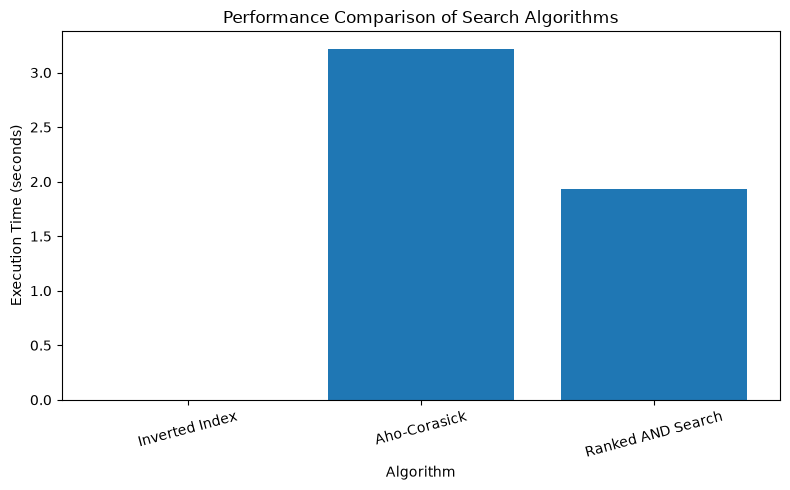

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_table["Algorithm"],
    results_table["Execution Time (seconds)"]
)

plt.xlabel("Algorithm")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Comparison of Search Algorithms")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()